# Personal Research Digest (Module 7)

This notebook upgrades Module 7 to a **Module-4-style multi-agent map-reduce workflow** while keeping a personal research focus.

It now produces **two outputs in one run**:
1. `final_report` (module-4 style long-form report)
2. `final_newsletter` (personal digest newsletter)

The pipeline also includes optional HITL interruption before analyst feedback and graph visualization for both subgraph and main graph.

## Setup

This notebook is notebook-first and uses Tavily retrieval + Gemini models.

Expected env vars:
- `GOOGLE_API_KEY`
- `TAVILY_API_KEY`

We auto-load `.env` from either:
- `module-7/.env`
- tutorial root `.env`

In [1]:
from __future__ import annotations

import json
import operator
import os
import re
from datetime import date, timedelta
from pathlib import Path
from typing import Annotated, Any, Dict, List, Literal, Optional, TypedDict
from urllib.parse import urlparse, urlunparse

from dotenv import load_dotenv
from pydantic import BaseModel, Field

from IPython.display import Image, Markdown, display

from langchain_core.messages import AIMessage, HumanMessage, SystemMessage, get_buffer_string
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_tavily import TavilySearch

from langgraph.constants import Send
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, START, MessagesState, StateGraph

/tmp/ipykernel_145007/2439449292.py:21: LangGraphDeprecatedSinceV10: Importing Send from langgraph.constants is deprecated. Please use 'from langgraph.types import Send' instead. Deprecated in LangGraph V1.0 to be removed in V2.0.
  from langgraph.constants import Send


In [2]:
CWD = Path.cwd()
if (CWD / "prompts").exists():
    MODULE_DIR = CWD
elif (CWD / "module-7" / "prompts").exists():
    MODULE_DIR = CWD / "module-7"
else:
    raise FileNotFoundError("Could not locate module-7 directory with prompts/")

PROMPTS_DIR = MODULE_DIR / "prompts"
DATA_DIR = MODULE_DIR / "data"

for env_path in [MODULE_DIR / ".env", MODULE_DIR.parent / ".env"]:
    if env_path.exists():
        load_dotenv(env_path, override=False)

assert PROMPTS_DIR.exists(), f"Missing prompts dir: {PROMPTS_DIR}"
assert DATA_DIR.exists(), f"Missing data dir: {DATA_DIR}"

CONFIG: Dict[str, Any] = {
    "fast_model": "gemini-2.5-flash",
    "quality_model": "gemini-2.5-pro",
    "max_results_per_query": 4,
    "max_analysts": 4,
    "max_num_turns": 2,
    "max_items_per_section": 4,
    "next_weekend_days": 2,
    "default_locations": ["Netherlands", "Limburg", "Maastricht", "Borgharen"],
    "default_languages": ["en", "it", "nl"],
}

print("Module directory:", MODULE_DIR)
print("GOOGLE_API_KEY loaded:", bool(os.getenv("GOOGLE_API_KEY")))
print("TAVILY_API_KEY loaded:", bool(os.getenv("TAVILY_API_KEY")))

Module directory: /home/roberto/workspace/workspace-root-langgraph/langchain-langgraph-tutorial/module-7
GOOGLE_API_KEY loaded: True
TAVILY_API_KEY loaded: True


In [3]:
fast_llm = ChatGoogleGenerativeAI(model=CONFIG["fast_model"], temperature=0)
quality_llm = ChatGoogleGenerativeAI(model=CONFIG["quality_model"], temperature=0)
search_tool = TavilySearch(max_results=CONFIG["max_results_per_query"])

LOW_SIGNAL_DOMAINS = {
    "youtube.com", "www.youtube.com",
    "instagram.com", "www.instagram.com",
    "facebook.com", "www.facebook.com",
    "tiktok.com", "www.tiktok.com",
}
AGGREGATOR_DOMAINS = {"ground.news", "www.ground.news"}


def load_json(path: Path, default: Any) -> Any:
    if not path.exists():
        return default
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def save_json(path: Path, payload: Any) -> None:
    with path.open("w", encoding="utf-8") as f:
        json.dump(payload, f, ensure_ascii=True, indent=2)


def normalize_text(text: str, max_len: int = 300) -> str:
    clean = re.sub(r"\s+", " ", (text or "")).strip()
    if len(clean) <= max_len:
        return clean
    return clean[: max_len - 1].rstrip() + "..."


def normalize_url(url: str) -> str:
    if not url:
        return ""
    try:
        p = urlparse(url.strip())
        return urlunparse((p.scheme.lower(), p.netloc.lower(), p.path.rstrip("/"), "", "", ""))
    except Exception:
        return url.strip().lower()


def domain_from_url(url: str) -> str:
    try:
        return urlparse(url).netloc.lower() or "unknown"
    except Exception:
        return "unknown"


def source_quality_adjustment(source: str) -> float:
    source = (source or "").lower()
    if source in LOW_SIGNAL_DOMAINS:
        return -0.25
    if source in AGGREGATOR_DOMAINS:
        return -0.12
    if "government.nl" in source or source.endswith(".gov"):
        return 0.10
    if source in {"nos.nl", "www.nos.nl", "reuters.com", "www.reuters.com", "apnews.com", "www.apnews.com"}:
        return 0.08
    return 0.0


def clamp(v: float, lo: float = 0.0, hi: float = 1.0) -> float:
    return max(lo, min(hi, v))


def get_next_weekend_window(today: Optional[date] = None) -> tuple[date, date]:
    today = today or date.today()
    days_until_sat = (5 - today.weekday()) % 7
    if days_until_sat == 0:
        days_until_sat = 7
    start = today + timedelta(days=days_until_sat)
    end = start + timedelta(days=CONFIG["next_weekend_days"] - 1)
    return start, end


def tavily_results(query: str) -> List[Dict[str, Any]]:
    raw = search_tool.invoke({"query": query})
    if isinstance(raw, dict):
        return raw.get("results", [])
    if isinstance(raw, list):
        return raw
    return []

## Prompt Pack

We reuse module-7 prompt files for personal domain grounding and then compose richer instructions in code (same pattern as module-4).

In [4]:
PROMPT_FILES = {
    "planner": "planner.md",
    "news": "news_analyst.md",
    "events": "events_analyst.md",
    "bitcoin": "bitcoin_analyst.md",
    "personalizer": "personalizer.md",
    "output": "output.md",
}
PROMPTS = {
    name: (PROMPTS_DIR / file_name).read_text(encoding="utf-8")
    for name, file_name in PROMPT_FILES.items()
}
print("Loaded prompts:", sorted(PROMPTS.keys()))

Loaded prompts: ['bitcoin', 'events', 'news', 'output', 'personalizer', 'planner']


## Schemas and State

We adopt module-4 style typed state while adding personal digest artifacts.

In [5]:
class Analyst(BaseModel):
    name: str
    role: str
    beat: Literal["news", "events", "bitcoin"]
    focus: str
    affiliation: str = "Independent research desk"

    @property
    def persona(self) -> str:
        return (
            f"Name: {self.name}\n"
            f"Role: {self.role}\n"
            f"Beat: {self.beat}\n"
            f"Focus: {self.focus}\n"
            f"Affiliation: {self.affiliation}"
        )


class Perspectives(BaseModel):
    analysts: List[Analyst]


class SearchQuery(BaseModel):
    search_query: str


class NewsItem(BaseModel):
    title: str
    source: str
    url: str
    region: str
    category: str
    summary: str
    why_it_matters: str
    relevance_score: float = Field(ge=0.0, le=1.0)


class EventItem(BaseModel):
    title: str
    source: str
    url: str
    location: str
    date_text: str
    category: str
    summary: str
    family_friendly: bool
    distance_hint: str
    relevance_score: float = Field(ge=0.0, le=1.0)


class BitcoinItem(BaseModel):
    title: str
    source: str
    url: str
    category: Literal["market", "technical", "community"]
    summary: str
    why_it_matters: str
    technical_level: Literal["basic", "intermediate", "advanced"]
    relevance_score: float = Field(ge=0.0, le=1.0)


class MultilingualRecap(BaseModel):
    english: str
    italian: str
    dutch: str


class GenerateAnalystsState(TypedDict, total=False):
    user_request: str
    max_analysts: int
    human_analyst_feedback: str
    analysts: List[Analyst]
    execution_notes: Annotated[List[str], operator.add]


class InterviewState(MessagesState):
    analyst: Analyst
    context: Annotated[List[str], operator.add]
    raw_results: Annotated[List[Dict[str, Any]], operator.add]
    interview: str
    section: str
    collected_news: List[NewsItem]
    collected_events: List[EventItem]
    collected_bitcoin: List[BitcoinItem]


class ResearchGraphState(TypedDict, total=False):
    user_request: str
    max_analysts: int
    human_analyst_feedback: str
    analysts: List[Analyst]

    sections: Annotated[List[str], operator.add]
    collected_news: Annotated[List[NewsItem], operator.add]
    collected_events: Annotated[List[EventItem], operator.add]
    collected_bitcoin: Annotated[List[BitcoinItem], operator.add]

    introduction: str
    content: str
    conclusion: str
    final_report: str

    newsletter_news: List[NewsItem]
    newsletter_events: List[EventItem]
    newsletter_bitcoin: List[BitcoinItem]
    final_newsletter: str
    multilingual_recap: MultilingualRecap

    execution_notes: Annotated[List[str], operator.add]

In [6]:
SEEN_ITEMS_PATH = DATA_DIR / "seen_items.json"
PREFERENCES_PATH = DATA_DIR / "user_preferences.json"


def load_preferences() -> Dict[str, Any]:
    prefs = load_json(PREFERENCES_PATH, {})
    if not isinstance(prefs, dict):
        prefs = {}
    prefs.setdefault("locations", CONFIG["default_locations"])
    prefs.setdefault("preferred_categories", ["local", "economy", "finance", "events", "bitcoin"])
    prefs.setdefault("languages", CONFIG["default_languages"])
    prefs.setdefault("family_friendly_priority", True)
    return prefs


def load_seen_items() -> set[str]:
    payload = load_json(SEEN_ITEMS_PATH, {"seen_items": []})
    seen = payload.get("seen_items", []) if isinstance(payload, dict) else []
    return set(str(x) for x in seen)


def persist_seen_items(seen_ids: set[str]) -> None:
    save_json(SEEN_ITEMS_PATH, {"seen_items": sorted(seen_ids)})


def canonical_item_id(url: str, title: str) -> str:
    clean_url = normalize_url(url)
    if clean_url:
        return clean_url
    slug = re.sub(r"[^a-z0-9]+", "-", title.strip().lower()).strip("-")
    return "title:" + slug


def dedupe_keep_best(items: List[BaseModel]) -> List[BaseModel]:
    by_id: Dict[str, BaseModel] = {}
    for item in items:
        item_id = canonical_item_id(getattr(item, "url", ""), getattr(item, "title", ""))
        if item_id not in by_id:
            by_id[item_id] = item
            continue
        if getattr(item, "relevance_score", 0.0) > getattr(by_id[item_id], "relevance_score", 0.0):
            by_id[item_id] = item
    return list(by_id.values())


def apply_personalization(items: List[BaseModel], preferences: Dict[str, Any], seen_ids: set[str]) -> List[BaseModel]:
    boosted: List[BaseModel] = []
    preferred_locations = [loc.lower() for loc in preferences.get("locations", [])]
    preferred_categories = [cat.lower() for cat in preferences.get("preferred_categories", [])]

    for item in items:
        source = str(getattr(item, "source", "")).lower()
        if source in LOW_SIGNAL_DOMAINS:
            continue

        score = float(getattr(item, "relevance_score", 0.0))
        blob = " ".join([
            str(getattr(item, "region", "")),
            str(getattr(item, "location", "")),
            str(getattr(item, "summary", "")),
        ]).lower()

        if any(loc in blob for loc in preferred_locations):
            score += 0.15

        category = str(getattr(item, "category", "")).lower()
        if category in preferred_categories:
            score += 0.10

        score += source_quality_adjustment(source)

        item_id = canonical_item_id(getattr(item, "url", ""), getattr(item, "title", ""))
        if item_id in seen_ids:
            score -= 0.25

        setattr(item, "relevance_score", clamp(score))
        boosted.append(item)

    ranked = sorted(boosted, key=lambda x: getattr(x, "relevance_score", 0.0), reverse=True)
    filtered = [x for x in ranked if getattr(x, "relevance_score", 0.0) >= 0.35]
    return filtered if filtered else ranked

## Generate Analysts (HITL-Friendly)

This mirrors module-4: analyst creation + optional feedback loop.

In [7]:
ANALYST_INSTRUCTIONS = """You are generating AI analyst personas for a personal research digest.

Topic:
{topic}

User request:
{user_request}

Optional editorial feedback:
{human_analyst_feedback}

Create exactly {max_analysts} analysts with focused, non-overlapping beats.
Must cover these beats overall: news, events, bitcoin.
Keep each focus concrete and local-aware for Netherlands/Limburg/Maastricht/Borgharen where relevant.
"""

DEFAULT_ANALYSTS = [
    Analyst(name="Nora", role="Macro & Policy Analyst", beat="news", focus="Netherlands economy, taxes, and policy implications"),
    Analyst(name="Luca", role="Regional News Analyst", beat="news", focus="Limburg, Maastricht, and Borgharen local developments"),
    Analyst(name="Sanne", role="Local Events Analyst", beat="events", focus="Next-weekend events near Maastricht with family-friendly priority"),
    Analyst(name="Mika", role="Bitcoin Analyst", beat="bitcoin", focus="Bitcoin market, BIPs/protocol, community and nearby meetups"),
]


def enforce_beat_coverage(analysts: List[Analyst], max_analysts: int) -> List[Analyst]:
    if not analysts:
        return DEFAULT_ANALYSTS[:max_analysts]

    beats = {a.beat for a in analysts}
    for beat in ["news", "events", "bitcoin"]:
        if beat not in beats:
            for d in DEFAULT_ANALYSTS:
                if d.beat == beat:
                    analysts.append(d)
                    break

    return analysts[:max_analysts]


def create_analysts(state: GenerateAnalystsState) -> Dict[str, Any]:
    topic = state.get("topic", "Personal research digest")
    user_request = state.get("user_request", topic)
    max_analysts = state.get("max_analysts", CONFIG["max_analysts"])
    human_analyst_feedback = state.get("human_analyst_feedback", "")

    structured_llm = fast_llm.with_structured_output(Perspectives)
    system_msg = ANALYST_INSTRUCTIONS.format(
        topic=topic,
        user_request=user_request,
        max_analysts=max_analysts,
        human_analyst_feedback=human_analyst_feedback,
    )

    try:
        generated = structured_llm.invoke([
            SystemMessage(content=system_msg),
            HumanMessage(content="Generate analyst personas."),
        ])
        analysts = enforce_beat_coverage(generated.analysts, max_analysts)
    except Exception:
        analysts = DEFAULT_ANALYSTS[:max_analysts]

    return {
        "analysts": analysts,
        "execution_notes": [f"Generated {len(analysts)} analysts."],
    }


def human_feedback(state: GenerateAnalystsState):
    return {"execution_notes": ["Waiting for optional human feedback."]}


def should_continue_after_feedback(state: GenerateAnalystsState):
    if state.get("human_analyst_feedback"):
        return "create_analysts"
    return END

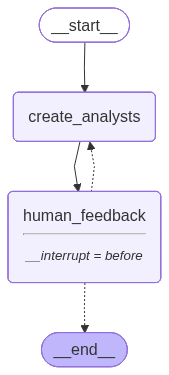

In [8]:
gen_builder = StateGraph(GenerateAnalystsState)
gen_builder.add_node("create_analysts", create_analysts)
gen_builder.add_node("human_feedback", human_feedback)
gen_builder.add_edge(START, "create_analysts")
gen_builder.add_edge("create_analysts", "human_feedback")
gen_builder.add_conditional_edges("human_feedback", should_continue_after_feedback, ["create_analysts", END])
gen_graph = gen_builder.compile(checkpointer=MemorySaver(), interrupt_before=["human_feedback"])

try:
    display(Image(gen_graph.get_graph(xray=1).draw_mermaid_png()))
except Exception as e:
    print("Graph render unavailable in this environment:", e)

## Conduct Interview (Subgraph)

Like module-4, each analyst runs a mini interview loop:
- generate question
- retrieve web context (Tavily)
- answer with citations
- loop by `max_num_turns`
- save interview + write section memo
- convert retrievals into structured digest candidates

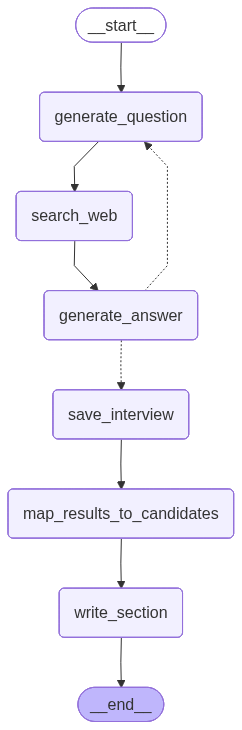

In [9]:
QUESTION_INSTRUCTIONS = """You are an analyst interviewing an expert for this persona:

{persona}

Ask one specific question that improves a newsletter-grade understanding of your beat.
When enough info has been gathered, end with: Thank you so much for your help!"""

SEARCH_INSTRUCTIONS = """Given the conversation, produce a concise web-search query for the latest relevant evidence.
Prioritize recent, specific, and sourceable results."""

ANSWER_INSTRUCTIONS = """You are an expert being interviewed by an analyst.
Use only this context:

{context}

Rules:
1. Ground claims in provided context only.
2. Cite sources inline like [1], [2].
3. End with a Sources list mapping ids to URLs/domains.
"""

SECTION_WRITER_INSTRUCTIONS = """You are writing an analyst memo for a personal research report.

Beat: {beat}
Topic: {topic}

Interview transcript:
{interview}

Write markdown memo with:
- `### {beat_title}` heading
- 3-5 concise insight bullets
- clear local/personal impact
- preserve source references if present
"""


def generate_question(state: InterviewState) -> Dict[str, Any]:
    analyst = state["analyst"]
    messages = state["messages"]
    system_msg = QUESTION_INSTRUCTIONS.format(persona=analyst.persona)
    question = fast_llm.invoke([SystemMessage(content=system_msg)] + messages)
    return {"messages": [question]}


def search_web(state: InterviewState) -> Dict[str, Any]:
    messages = state["messages"]
    structured_llm = fast_llm.with_structured_output(SearchQuery)

    query_obj = structured_llm.invoke([
        SystemMessage(content=SEARCH_INSTRUCTIONS),
        *messages,
    ])

    results = tavily_results(query_obj.search_query)
    formatted_docs = "\n\n---\n\n".join(
        f'<Document href="{normalize_url(doc.get("url", ""))}"/>\n{normalize_text(doc.get("content", ""), 600)}\n</Document>'
        for doc in results
    )

    return {
        "context": [formatted_docs] if formatted_docs else [""],
        "raw_results": results,
    }


def generate_answer(state: InterviewState) -> Dict[str, Any]:
    messages = state["messages"]
    context = "\n\n".join(state.get("context", []))

    system_msg = ANSWER_INSTRUCTIONS.format(context=context)
    answer = fast_llm.invoke([SystemMessage(content=system_msg)] + messages)
    answer.name = "expert"
    return {"messages": [answer]}


def route_messages(state: InterviewState, expert_name: str = "expert"):
    messages = state["messages"]
    max_turns = CONFIG["max_num_turns"]

    num_expert_replies = len([m for m in messages if isinstance(m, AIMessage) and m.name == expert_name])
    if num_expert_replies >= max_turns:
        return "save_interview"

    if len(messages) >= 2:
        last_question = messages[-2]
        if hasattr(last_question, "content") and "Thank you so much for your help" in str(last_question.content):
            return "save_interview"

    return "generate_question"


def save_interview(state: InterviewState) -> Dict[str, Any]:
    interview = get_buffer_string(state["messages"])
    return {"interview": interview}


def map_results_to_candidates(state: InterviewState) -> Dict[str, Any]:
    beat = state["analyst"].beat
    raw_results = state.get("raw_results", [])

    news_items: List[NewsItem] = []
    event_items: List[EventItem] = []
    bitcoin_items: List[BitcoinItem] = []

    weekend_start, weekend_end = get_next_weekend_window()
    weekend_text = f"{weekend_start.isoformat()} to {weekend_end.isoformat()}"

    for r in raw_results[:6]:
        title = normalize_text(r.get("title") or "Untitled")
        url = normalize_url(r.get("url") or "")
        source = domain_from_url(url)
        summary = normalize_text(r.get("content") or "No summary available")
        score = clamp(float(r.get("score", 0.5)))

        if beat == "news":
            region = "Limburg/Maastricht" if any(x in (title + summary).lower() for x in ["limburg", "maastricht", "borgharen"]) else "Netherlands"
            category = "local" if region != "Netherlands" else "economy"
            news_items.append(NewsItem(
                title=title,
                source=source,
                url=url,
                region=region,
                category=category,
                summary=summary,
                why_it_matters="Potential impact on personal planning, policy awareness, or finances.",
                relevance_score=score,
            ))
        elif beat == "events":
            blob = (title + " " + summary).lower()
            family_friendly = any(k in blob for k in ["family", "kids", "children", "all ages"])
            loc = "Maastricht/Limburg"
            if "borgharen" in blob:
                loc = "Borgharen"
            elif "maastricht" in blob:
                loc = "Maastricht"
            elif "limburg" in blob:
                loc = "Limburg"
            event_items.append(EventItem(
                title=title,
                source=source,
                url=url,
                location=loc,
                date_text=f"Next weekend ({weekend_text})",
                category="events",
                summary=summary,
                family_friendly=family_friendly,
                distance_hint="Near Maastricht area",
                relevance_score=score,
            ))
        else:
            blob = (title + " " + summary).lower()
            if any(k in blob for k in ["bip", "protocol", "fork"]):
                cat = "technical"
                level = "advanced"
            elif any(k in blob for k in ["meetup", "conference", "community"]):
                cat = "community"
                level = "intermediate"
            else:
                cat = "market"
                level = "basic"
            bitcoin_items.append(BitcoinItem(
                title=title,
                source=source,
                url=url,
                category=cat,
                summary=summary,
                why_it_matters="May affect positioning, technical awareness, or local participation.",
                technical_level=level,
                relevance_score=score,
            ))

    return {
        "collected_news": news_items,
        "collected_events": event_items,
        "collected_bitcoin": bitcoin_items,
    }


def write_section(state: InterviewState) -> Dict[str, Any]:
    analyst = state["analyst"]
    interview = state.get("interview", "")
    topic = "Personal research digest"

    beat_title = {
        "news": "News Analyst Memo",
        "events": "Events Analyst Memo",
        "bitcoin": "Bitcoin Analyst Memo",
    }[analyst.beat]

    instructions = SECTION_WRITER_INSTRUCTIONS.format(
        beat=analyst.beat,
        beat_title=beat_title,
        topic=topic,
        interview=interview,
    )

    section = quality_llm.invoke([
        SystemMessage(content=instructions),
        HumanMessage(content="Write the memo section."),
    ])

    return {"section": section.content}


interview_builder = StateGraph(InterviewState)
interview_builder.add_node("generate_question", generate_question)
interview_builder.add_node("search_web", search_web)
interview_builder.add_node("generate_answer", generate_answer)
interview_builder.add_node("save_interview", save_interview)
interview_builder.add_node("map_results_to_candidates", map_results_to_candidates)
interview_builder.add_node("write_section", write_section)

interview_builder.add_edge(START, "generate_question")
interview_builder.add_edge("generate_question", "search_web")
interview_builder.add_edge("search_web", "generate_answer")
interview_builder.add_conditional_edges("generate_answer", route_messages, ["generate_question", "save_interview"])
interview_builder.add_edge("save_interview", "map_results_to_candidates")
interview_builder.add_edge("map_results_to_candidates", "write_section")
interview_builder.add_edge("write_section", END)

interview_graph = interview_builder.compile()

try:
    display(Image(interview_graph.get_graph(xray=1).draw_mermaid_png()))
except Exception as e:
    print("Interview graph render unavailable:", e)

## Map-Reduce Main Graph

This section mirrors module-4 orchestration:
- create analysts
- optional feedback interrupt
- run interview subgraph in parallel via `Send`
- write report content/introduction/conclusion
- finalize report
- derive personalized newsletter + multilingual recap

In [10]:
REPORT_WRITER_INSTRUCTIONS = """You are writing a high-quality report on this personal research topic:
{topic}

You are given memo sections from multiple analysts.

Output requirements:
1. Markdown only.
2. Start with `## Insights`.
3. Synthesize cross-cutting insights and remove duplication.
4. Include practical implications for: local life, finance/economy, and bitcoin awareness.
5. End with `## Sources` and unique source lines.

Memos:
{context}
"""

INTRO_CONCLUSION_INSTRUCTIONS = """You are finishing a report on {topic}.
Given all sections, write either an introduction or conclusion.

Rules:
- Markdown only.
- Introduction must include a title header (`# ...`) and `## Introduction`.
- Conclusion must use `## Conclusion`.
- ~100 words each.
- No preamble.

Sections:
{sections}
"""

MULTILINGUAL_RECAP_INSTRUCTIONS = """Create short recaps from this newsletter.

Return JSON fields:
- english
- italian
- dutch

Each recap should be 70-120 words and action-oriented.

Newsletter:
{newsletter}
"""


def initiate_all_interviews(state: ResearchGraphState):
    if state.get("human_analyst_feedback"):
        return "create_analysts"

    topic = state.get("topic") or state.get("user_request", "Personal research digest")
    sends = []
    for analyst in state["analysts"]:
        sends.append(
            Send(
                "conduct_interview",
                {
                    "analyst": analyst,
                    "messages": [
                        HumanMessage(content=f"You are preparing a personal digest on: {topic}. Start the interview.")
                    ],
                },
            )
        )
    return sends


def collect_interview_outputs(state: ResearchGraphState) -> Dict[str, Any]:
    return {"execution_notes": ["Interview map phase completed."]}


def write_report(state: ResearchGraphState) -> Dict[str, Any]:
    sections = state.get("sections", [])
    topic = state.get("topic") or state.get("user_request", "Personal research digest")
    context = "\n\n".join(sections) if sections else "No memos available."

    msg = REPORT_WRITER_INSTRUCTIONS.format(topic=topic, context=context)
    report = quality_llm.invoke([
        SystemMessage(content=msg),
        HumanMessage(content="Write the consolidated report."),
    ])
    return {"content": report.content}


def write_introduction(state: ResearchGraphState) -> Dict[str, Any]:
    sections = "\n\n".join(state.get("sections", []))
    topic = state.get("topic") or state.get("user_request", "Personal research digest")
    msg = INTRO_CONCLUSION_INSTRUCTIONS.format(topic=topic, sections=sections)
    intro = quality_llm.invoke([
        SystemMessage(content=msg),
        HumanMessage(content="Write the report introduction."),
    ])
    return {"introduction": intro.content}


def write_conclusion(state: ResearchGraphState) -> Dict[str, Any]:
    sections = "\n\n".join(state.get("sections", []))
    topic = state.get("topic") or state.get("user_request", "Personal research digest")
    msg = INTRO_CONCLUSION_INSTRUCTIONS.format(topic=topic, sections=sections)
    conclusion = quality_llm.invoke([
        SystemMessage(content=msg),
        HumanMessage(content="Write the report conclusion."),
    ])
    return {"conclusion": conclusion.content}


def finalize_report(state: ResearchGraphState) -> Dict[str, Any]:
    content = state.get("content", "")
    intro = state.get("introduction", "# Personal Research Report\n\n## Introduction\nNo introduction generated.")
    conclusion = state.get("conclusion", "## Conclusion\nNo conclusion generated.")

    insights = content
    sources_block = ""
    if "## Sources" in content:
        parts = content.split("## Sources", 1)
        insights = parts[0].strip()
        sources_block = "## Sources\n" + parts[1].strip()

    if "## Insights" not in insights:
        insights = "## Insights\n" + insights.strip()

    final_report = intro.strip() + "\n\n---\n\n" + insights.strip() + "\n\n---\n\n" + conclusion.strip()
    if sources_block:
        final_report += "\n\n" + sources_block

    return {
        "final_report": final_report,
        "execution_notes": ["Final report assembled."],
    }


def personalize_newsletter_data(state: ResearchGraphState) -> Dict[str, Any]:
    prefs = load_preferences()
    seen_ids = load_seen_items()

    news = dedupe_keep_best(state.get("collected_news", []))
    events = dedupe_keep_best(state.get("collected_events", []))
    bitcoin = dedupe_keep_best(state.get("collected_bitcoin", []))

    news = apply_personalization(news, prefs, seen_ids)[: CONFIG["max_items_per_section"]]
    events = apply_personalization(events, prefs, seen_ids)[: CONFIG["max_items_per_section"]]
    bitcoin = apply_personalization(bitcoin, prefs, seen_ids)[: CONFIG["max_items_per_section"]]

    for coll in (news, events, bitcoin):
        for item in coll:
            seen_ids.add(canonical_item_id(getattr(item, "url", ""), getattr(item, "title", "")))
    persist_seen_items(seen_ids)

    return {
        "newsletter_news": news,
        "newsletter_events": events,
        "newsletter_bitcoin": bitcoin,
        "execution_notes": [f"Newsletter selection complete: news={len(news)}, events={len(events)}, bitcoin={len(bitcoin)}."],
    }



def _md_link(label: str, url: str) -> str:
    clean = normalize_url(url)
    if not clean:
        return label
    return f"[{label}]({clean})"


def _render_section(items: List[BaseModel], empty_text: str) -> str:
    if not items:
        return "- " + empty_text
    lines = []
    for i, item in enumerate(items, start=1):
        title = getattr(item, "title", "Untitled")
        source = getattr(item, "source", "unknown")
        url = getattr(item, "url", "")
        summary = getattr(item, "summary", "")
        lines.append(
            f"- **{i}. {_md_link(title, url)}**  \
"
            f"  Source: `{source}`  \
"
            f"  Why it matters: {summary}"
        )
    return "\n".join(lines)


def _split_news(news: List[NewsItem]) -> tuple[List[NewsItem], List[NewsItem]]:
    national, local = [], []
    for n in news:
        region = (n.region or "").lower()
        if region == "netherlands":
            national.append(n)
        else:
            local.append(n)
    return national, local


def _split_bitcoin(bitcoin: List[BitcoinItem]) -> tuple[List[BitcoinItem], List[BitcoinItem], List[BitcoinItem]]:
    market, technical, community = [], [], []
    for b in bitcoin:
        if b.category == "technical":
            technical.append(b)
        elif b.category == "community":
            community.append(b)
        else:
            market.append(b)
    return market, technical, community


def write_newsletter(state: ResearchGraphState) -> Dict[str, Any]:
    news = state.get("newsletter_news", [])
    events = state.get("newsletter_events", [])
    bitcoin = state.get("newsletter_bitcoin", [])
    weekend_start, weekend_end = get_next_weekend_window()

    national_news, local_news = _split_news(news)
    btc_market, btc_technical, btc_community = _split_bitcoin(bitcoin)

    source_lines = []
    seen_src = set()
    for coll in (news, events, bitcoin):
        for item in coll:
            key = canonical_item_id(getattr(item, "url", ""), getattr(item, "title", ""))
            if key in seen_src:
                continue
            seen_src.add(key)
            source = getattr(item, "source", "unknown")
            url = getattr(item, "url", "")
            source_lines.append(f"- {_md_link(source, url)}")

    newsletter = "\n".join([
        f"# Personal Research Newsletter ({date.today().isoformat()})",
        "",
        "## Weekly Signal",
        "A richer snapshot of what matters this week across policy, local life, and Bitcoin.",
        "",
        "## Quick Glance",
        f"- National news signals: **{len(national_news)}**",
        f"- Local Limburg/Maastricht/Borgharen signals: **{len(local_news)}**",
        f"- Next-weekend events: **{len(events)}**",
        f"- Bitcoin signals: **{len(bitcoin)}** (market **{len(btc_market)}**, technical **{len(btc_technical)}**, community **{len(btc_community)}**)",
        "",
        "## Netherlands & Local News",
        "### National Policy & Economy",
        _render_section(national_news, "No strong national policy/economy signal found for this run."),
        "",
        "### Limburg / Maastricht / Borgharen",
        _render_section(local_news, "No strong local signal found for this run."),
        "",
        f"## Weekend Events ({weekend_start.isoformat()} to {weekend_end.isoformat()})",
        _render_section(events, "No reliable nearby event found for next weekend."),
        "",
        "## Bitcoin Corner",
        "### Market",
        _render_section(btc_market, "No strong Bitcoin market signal found for this run."),
        "",
        "### Technical (BIPs / Protocol)",
        _render_section(btc_technical, "No strong Bitcoin technical signal found for this run."),
        "",
        "### Community",
        _render_section(btc_community, "No strong Bitcoin community signal found for this run."),
        "",
        "## Action Checklist",
        "- Identify 1 local event to attend this weekend.",
        "- Review 2 high-signal policy/news items and note potential personal impact.",
        "- Track 1 Bitcoin market item and 1 technical/community item.",
        "",
        "## Sources",
        *(source_lines if source_lines else ["- No sources captured."]),
    ])

    return {
        "final_newsletter": newsletter,
        "execution_notes": ["Personal newsletter rendered."],
    }

def build_multilingual_recap(state: ResearchGraphState) -> Dict[str, Any]:
    newsletter = state.get("final_newsletter", "")
    structured = quality_llm.with_structured_output(MultilingualRecap)
    try:
        recap = structured.invoke([
            SystemMessage(content=MULTILINGUAL_RECAP_INSTRUCTIONS.format(newsletter=newsletter)),
            HumanMessage(content="Generate EN/IT/NL recaps."),
        ])
    except Exception:
        recap = MultilingualRecap(
            english="Recap generation unavailable.",
            italian="Generazione riepilogo non disponibile.",
            dutch="Samenvatting genereren niet beschikbaar.",
        )
    return {
        "multilingual_recap": recap,
        "execution_notes": ["Multilingual recap generated."],
    }

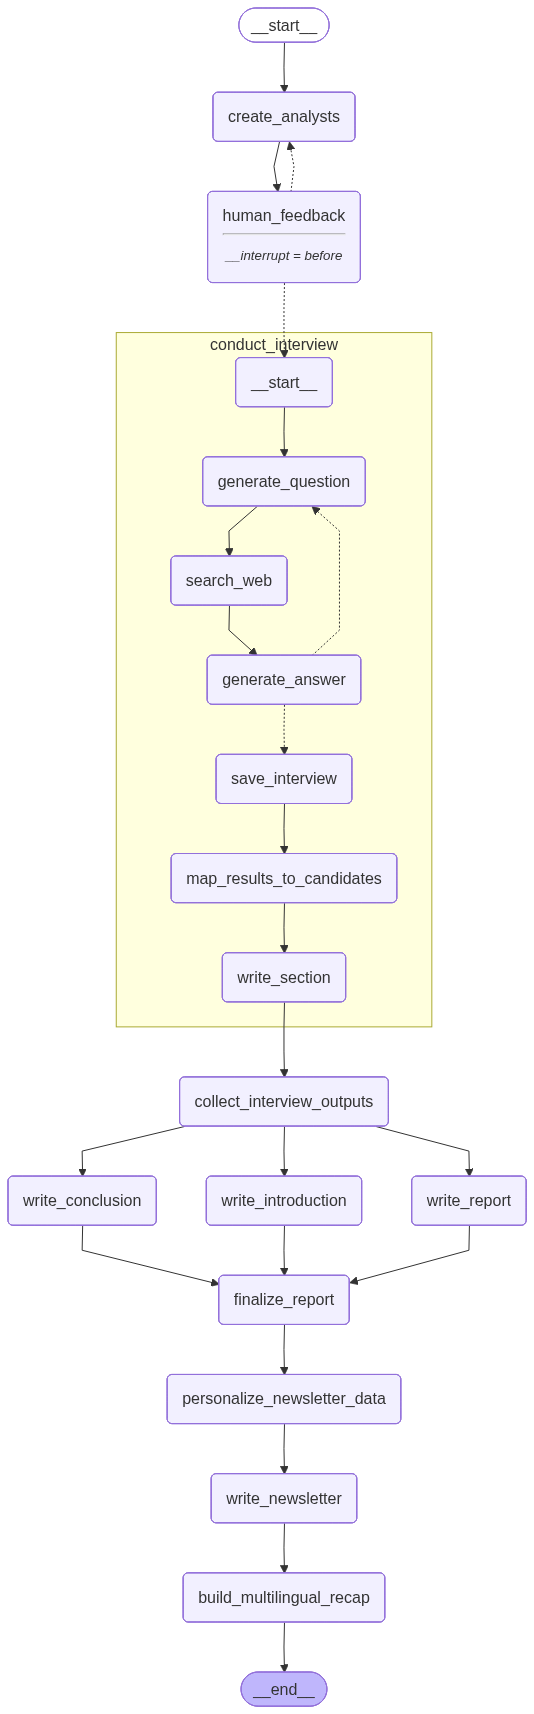

Graphs compiled.


In [11]:
main_builder = StateGraph(ResearchGraphState)

main_builder.add_node("create_analysts", create_analysts)
main_builder.add_node("human_feedback", human_feedback)
main_builder.add_node("conduct_interview", interview_graph)
main_builder.add_node("collect_interview_outputs", collect_interview_outputs)

main_builder.add_node("write_report", write_report)
main_builder.add_node("write_introduction", write_introduction)
main_builder.add_node("write_conclusion", write_conclusion)
main_builder.add_node("finalize_report", finalize_report)

main_builder.add_node("personalize_newsletter_data", personalize_newsletter_data)
main_builder.add_node("write_newsletter", write_newsletter)
main_builder.add_node("build_multilingual_recap", build_multilingual_recap)

main_builder.add_edge(START, "create_analysts")
main_builder.add_edge("create_analysts", "human_feedback")
main_builder.add_conditional_edges("human_feedback", initiate_all_interviews, ["create_analysts", "conduct_interview"])

main_builder.add_edge("conduct_interview", "collect_interview_outputs")
main_builder.add_edge("collect_interview_outputs", "write_report")
main_builder.add_edge("collect_interview_outputs", "write_introduction")
main_builder.add_edge("collect_interview_outputs", "write_conclusion")
main_builder.add_edge(["write_report", "write_introduction", "write_conclusion"], "finalize_report")

main_builder.add_edge("finalize_report", "personalize_newsletter_data")
main_builder.add_edge("personalize_newsletter_data", "write_newsletter")
main_builder.add_edge("write_newsletter", "build_multilingual_recap")
main_builder.add_edge("build_multilingual_recap", END)

memory = MemorySaver()
main_graph_hitl = main_builder.compile(interrupt_before=["human_feedback"], checkpointer=memory)
main_graph = main_builder.compile(checkpointer=memory)

try:
    display(Image(main_graph_hitl.get_graph(xray=1).draw_mermaid_png()))
except Exception as e:
    print("Main graph render unavailable:", e)

print("Graphs compiled.")

## Demo Run (No Interrupt)

This run executes end-to-end without pausing at `human_feedback`.

In [12]:
demo_input = {
    "user_request": (
        "Create a personal research digest covering Netherlands economy/tax news, "
        "Limburg-Maastricht-Borgharen local developments, nearby next-weekend events, "
        "and Bitcoin market/technical/community updates."
    ),
    "topic": "Personal weekly digest for Netherlands + Limburg + Bitcoin",
    "max_analysts": CONFIG["max_analysts"],
    "max_num_turns": CONFIG["max_num_turns"],
}

result = main_graph.invoke(demo_input, config={"configurable": {"thread_id": "module7-demo"}})

print("Execution notes:")
for n in result.get("execution_notes", []):
    print("-", n)

print("\nSelected counts:")
print("- newsletter news:", len(result.get("newsletter_news", [])))
print("- newsletter events:", len(result.get("newsletter_events", [])))
print("- newsletter bitcoin:", len(result.get("newsletter_bitcoin", [])))

Execution notes:
- Generated 4 analysts.
- Waiting for optional human feedback.
- Interview map phase completed.
- Final report assembled.
- Newsletter selection complete: news=4, events=2, bitcoin=3.
- Personal newsletter rendered.
- Multilingual recap generated.

Selected counts:
- newsletter news: 4
- newsletter events: 2
- newsletter bitcoin: 3


In [13]:
display(Markdown("## Final Report"))
display(Markdown(result.get("final_report", "")))

display(Markdown("## Final Newsletter"))
display(Markdown(result.get("final_newsletter", "")))

## Final Report

# Personal Research Digest: Week in Review

## Introduction

This digest provides a consolidated overview of key developments across national, local, and digital spheres. We begin with a macro perspective, examining significant news in the Dutch economy and tax landscape. The focus then narrows to hyper-local updates from the Limburg-Maastricht-Borgharen region, covering important community developments. For leisure and planning, the report highlights notable events scheduled for the upcoming weekend. Finally, we shift to the digital asset space, providing a comprehensive update on Bitcoin's market performance, technical progress, and community sentiment. This briefing synthesizes diverse information streams into a single, actionable report.

---

## Insights

This digest synthesizes recent developments across the Dutch national economy, local affairs in the Limburg region, and the global Bitcoin landscape. A key cross-cutting theme is the tension between macroeconomic pressures, such as inflation, and microeconomic responses at both the local and individual levels. National fiscal policies aimed at curbing inflation and adjusting the tax code have direct implications for household budgets in Maastricht and the region's attractiveness for international talent. Concurrently, local investments in infrastructure and technology signal a forward-looking strategy for regional resilience and growth. In this environment, Bitcoin continues to be a subject of interest, both as a potential hedge against currency debasement and as a technological frontier relevant to the new high-tech initiatives in the region.

### Practical Implications for Local Life

*   **Borgharen Flood Defenses:** Recent municipal approvals for reinforcing the Meuse river defenses in the Borgharen area provide long-term security for residents, though short-term construction noise and access changes are expected. This is a direct local response to increasing climate-related risks.
*   **Weekend Mobility:** The "Culinary Maastricht" food festival at the Vrijthof this weekend will coincide with planned maintenance on the Noorderbrug bridge. Expect significant traffic delays and consider using public transport or park-and-ride facilities to access the city center.
*   **Household Budgets:** A proposed national increase in the low VAT (BTW) tariff from 9% to 10.5% on groceries and essential goods, intended to cool inflation, will directly impact weekly household expenses. Residents should anticipate a slight increase in the cost of living in the coming months.

### Practical Implications for Finance & Economy

*   **Expat & Tech Sector Impact:** The Dutch government is debating a reduction in the duration of the "30% ruling," a tax advantage for highly skilled migrants. This could affect the ability of Maastricht-based companies, including the new Brightlands Tech Campus, to attract top international talent, potentially slowing regional innovation.
*   **Investment Strategy:** Persistent inflation, as reported by the CBS, continues to erode the value of cash savings. This reinforces the importance of reviewing investment portfolios. The ongoing national discussion about adjusting the "Box 3" wealth tax adds another layer of uncertainty for investors with significant assets in savings and investments.
*   **Regional Economic Outlook:** The significant municipal and provincial investment in the Brightlands Tech Campus is a major positive indicator for the long-term economic health of South Limburg. This initiative aims to create high-value jobs and position the region as a hub for data science and sustainable technology, potentially boosting property values and local business opportunities over the next decade.

### Practical Implications for Bitcoin Awareness

*   **Inflation Hedge Narrative:** The Dutch government's struggle with persistent inflation provides a real-world context for one of Bitcoin's primary narratives: a store of value with a fixed supply, immune to central bank policy and currency debasement.
*   **Market Consolidation:** The Bitcoin price has been consolidating in a tight range, finding technical support around the $65,000 level. This period of low volatility is seen by analysts as a potential accumulation phase before the next major market move, which could be influenced by macroeconomic data releases from the US and Europe.
*   **Technological Development:** Community and developer discussions are intensifying around the potential activation of new "opcodes" (like OP_CAT) via a future soft fork. While highly technical, such upgrades could enable more complex smart contracts and decentralized finance (DeFi) applications on the Bitcoin base layer, expanding its utility beyond a simple payment and savings network. This aligns with the innovation focus of local tech hubs like Brightlands.

---

## Conclusion

This digest synthesizes a diverse range of information, bridging the gap between broad economic trends in the Netherlands and hyper-local developments in the Maastricht area. The inclusion of upcoming weekend events provides immediate, practical knowledge, while the deep dive into the Bitcoin ecosystem offers a global, digital perspective on market dynamics and technological progress. By weaving together these distinct threads—macroeconomic policy, community news, leisure, and digital finance—this report provides a holistic and actionable overview. This multi-faceted awareness is essential for navigating both the local environment and the evolving global landscape effectively.

## Sources
*   Centraal Bureau voor de Statistiek (CBS) - Monthly Inflation Figures
*   Rijksoverheid.nl - 2024 Preliminary Tax Plan Briefing
*   De Limburger - "Gemeenteraad Maastricht Keurt Plan Dijkversterking Borgharen Goed"
*   Gemeente Maastricht - Official Announcements & Traffic Advisories
*   Brightlands Campus - Press Release on New Tech Hub Expansion
*   Maastricht Events Calendar - "Culinary Maastricht Weekend" Program
*   Glassnode - Weekly On-Chain Market Analysis Report
*   Bitcoin Core GitHub Repository - Developer Mailing List Discussions

## Final Newsletter

# Personal Research Newsletter (2026-04-21)

## Weekly Signal
A richer snapshot of what matters this week across policy, local life, and Bitcoin.

## Quick Glance
- National news signals: **2**
- Local Limburg/Maastricht/Borgharen signals: **2**
- Next-weekend events: **2**
- Bitcoin signals: **3** (market **3**, technical **0**, community **0**)

## Netherlands & Local News
### National Policy & Economy
- **1. [Netherlands MOF Posts Information on Various Tax Changes for 2026](https://news.bloombergtax.com/daily-tax-report-international/netherlands-mof-posts-information-on-various-tax-changes-for-2026)**    Source: `news.bloombergtax.com`    Why it matters: The changes includes measures to: 1) reduce to 35.75 percent from 35.82 percent the first individual income tax band rate, increase to 37.56
- **2. [The 2026 Dutch tax plan: Impact on businesses | Global law firm](https://www.nortonrosefulbright.com/en/knowledge/publications/b96914c1/the-2026-dutch-tax-plan)**    Source: `www.nortonrosefulbright.com`    Why it matters: Companies will pay the top CIT rate of 25.8% on those taxable amounts over € 200,000. Adjustment of minimum capital rule for financial

### Limburg / Maastricht / Borgharen
- **1. [ENCI quarry, Pietersberg, Maastricht, Limburg, Netherlands](https://www.mindat.org/loc-61650.html)**    Source: `www.mindat.org`    Why it matters: 0 The ENCI quarry is a limestone quarry on the Meuse side of the Sint-Pietersberg (part of the Caestert Plateau) in the Dutch municipality of Maastricht. Opencast limestone ("marl") mining started here in 1926 with the establishment of the Eerste Nederlandse Cement Industrie (ENCI).
- **2. [Recovery of the ENCI Quarry](https://www.publicspace.org/works/-/project/k219-enci-quarry-reclamation-and-public-landscape-park)**    Source: `www.publicspace.org`    Why it matters: October 6, 2021 - If the quarry generated work and income, its relationship with the citizens of Maastricht was tense from the very start owing to the huge scale of the excavation, the question of permissible emissions, and transport of products .

## Weekend Events (2026-04-25 to 2026-04-26)
- **1. [Community Events in Maastricht, Netherlands - Eventbrite](https://www.eventbrite.com/b/netherlands--maastricht/community)**    Source: `www.eventbrite.com`    Why it matters: # Community events in Maastricht, Netherlands. Discover the best Community events in your area and online. ## Most popular events. Journée d’étude/studiedag "INCLU'Seum" 2026 primary image. Mon, Oct 12 • 9:00 AM. Check ticket price on event. Traject 'Van vlas tot linnen' met Stef Lemmens primary im...
- **2. [Meeting Communities Where Communities Meet: Borgharen and Itteren, Maastricht, The Netherlands](https://udspace.udel.edu/items/7a7def80-4800-45a6-b64a-fdac24c1f966)**    Source: `udspace.udel.edu`    Why it matters: University of Delaware UD Logo. # Meeting Communities Where Communities Meet: Borgharen and Itteren, Maastricht, The Netherlands. ## Files. Misc 73.pdf (456.76 KB). ## Date. ## Authors. ## Journal Title. ## Journal ISSN. ## Volume Title. ## Publisher. ## Abstract. This report focuses on the field t...

## Bitcoin Corner
### Market
- **1. [Bitcoin maximalism vs. | Matthew A. Schneider](https://www.linkedin.com/posts/realmattschneider_the-crypto-debate-keeps-saying-the-same-activity-7403825698487836673-YvSR)**    Source: `www.linkedin.com`    Why it matters: The crypto debate keeps saying the same: Bitcoin maximalism vs. everything else. Fun to watch. Not useful. I think institutional capital is
- **2. [The Great Digital Asset Schism: A Philosophical Analysis of ...](https://medium.com/thecapital/the-great-digital-asset-schism-a-philosophical-analysis-of-bitcoiners-and-altcoiners-0aae031eedaf)**    Source: `medium.com`    Why it matters: For maximalists, Bitcoin's core virtues — unparalleled security, absolute scarcity, and radical decentralisation — are non-negotiable and
- **3. [Bitcoin Maximalism: The Philosophy of One True ...](https://lightspark.com/glossary/bitcoin-maximalism)**    Source: `lightspark.com`    Why it matters: Bitcoin Maximalism significantly shapes the crypto industry's development, discourse, and market dynamics. Polarization: Fostering intense

### Technical (BIPs / Protocol)
- No strong Bitcoin technical signal found for this run.

### Community
- No strong Bitcoin community signal found for this run.

## Action Checklist
- Identify 1 local event to attend this weekend.
- Review 2 high-signal policy/news items and note potential personal impact.
- Track 1 Bitcoin market item and 1 technical/community item.

## Sources
- [news.bloombergtax.com](https://news.bloombergtax.com/daily-tax-report-international/netherlands-mof-posts-information-on-various-tax-changes-for-2026)
- [www.mindat.org](https://www.mindat.org/loc-61650.html)
- [www.publicspace.org](https://www.publicspace.org/works/-/project/k219-enci-quarry-reclamation-and-public-landscape-park)
- [www.nortonrosefulbright.com](https://www.nortonrosefulbright.com/en/knowledge/publications/b96914c1/the-2026-dutch-tax-plan)
- [www.eventbrite.com](https://www.eventbrite.com/b/netherlands--maastricht/community)
- [udspace.udel.edu](https://udspace.udel.edu/items/7a7def80-4800-45a6-b64a-fdac24c1f966)
- [www.linkedin.com](https://www.linkedin.com/posts/realmattschneider_the-crypto-debate-keeps-saying-the-same-activity-7403825698487836673-YvSR)
- [medium.com](https://medium.com/thecapital/the-great-digital-asset-schism-a-philosophical-analysis-of-bitcoiners-and-altcoiners-0aae031eedaf)
- [lightspark.com](https://lightspark.com/glossary/bitcoin-maximalism)

In [14]:
display(Markdown("## Multilingual Recap"))
recap = result.get("multilingual_recap")
if recap:
    display(Markdown(f"### EN\n{recap.english}"))
    display(Markdown(f"### IT\n{recap.italian}"))
    display(Markdown(f"### NL\n{recap.dutch}"))
else:
    print("No recap generated.")

## Multilingual Recap

### EN
This week, get ahead by understanding the upcoming 2026 Dutch tax plan. Key changes will affect both individual income tax rates and the corporate tax rate for amounts over €200,000. Locally, explore the history and public reclamation of the ENCI quarry in Maastricht. For the weekend, plan to attend a community event in the area. In the crypto space, the ongoing debate around Bitcoin maximalism continues to shape market dynamics. Use the action checklist to review the tax impacts, pick a local event to visit, and track the latest in the Bitcoin market discussion. Stay informed and engaged.

### IT
Questa settimana, preparati esaminando il piano fiscale olandese per il 2026. I cambiamenti principali influenzeranno sia le aliquote dell'imposta sul reddito delle persone fisiche sia l'aliquota dell'imposta sulle società per importi superiori a 200.000 €. A livello locale, esplora la storia e il recupero pubblico della cava ENCI a Maastricht. Per il fine settimana, pianifica di partecipare a un evento della comunità nella zona. Nello spazio crypto, il dibattito sul massimalismo di Bitcoin continua a modellare le dinamiche di mercato. Usa la checklist per analizzare l'impatto fiscale, scegliere un evento locale e seguire la discussione sul mercato Bitcoin.

### NL
Blijf deze week voorop door het Nederlandse belastingplan voor 2026 te begrijpen. Belangrijke wijzigingen zullen zowel de tarieven van de inkomstenbelasting als de vennootschapsbelasting voor bedragen boven de € 200.000 beïnvloeden. Verken lokaal de geschiedenis en de openbare herontwikkeling van de ENCI-groeve in Maastricht. Plan voor het weekend een bezoek aan een lokaal evenement in de omgeving. In de cryptowereld blijft het debat rond Bitcoin-maximalisme de marktdynamiek bepalen. Gebruik de actiechecklist om de fiscale gevolgen te beoordelen, een lokaal evenement te kiezen en de laatste ontwikkelingen in de Bitcoin-markt te volgen.

## HITL Path Check

This verifies that the HITL-compiled graph interrupts before `human_feedback`.

In [15]:
hitl_thread = {"configurable": {"thread_id": "module7-hitl-check"}}
_ = main_graph_hitl.invoke(demo_input, config=hitl_thread)
snapshot = main_graph_hitl.get_state(hitl_thread)
print("Next nodes at interruption:", snapshot.next)
assert snapshot.next and snapshot.next[0] == "human_feedback"
print("HITL interruption check passed.")

Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('__main__', 'Analyst')]
Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('__main__', 'Analyst')]
Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('__main__', 'Analyst')]
Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('__main__', 'Analyst')]


Next nodes at interruption: ('human_feedback',)
HITL interruption check passed.


## Validation and Acceptance Scenarios

In [16]:
final_report = result.get("final_report", "")
final_newsletter = result.get("final_newsletter", "")

assert "## Introduction" in final_report
assert "## Insights" in final_report
assert "## Conclusion" in final_report
assert "## Sources" in final_report

assert "# Personal Research Newsletter" in final_newsletter
assert "## Netherlands & Local News" in final_newsletter
assert "## Weekend Events" in final_newsletter
assert "## Bitcoin Corner" in final_newsletter
assert "## Action Checklist" in final_newsletter
assert "## Sources" in final_newsletter

recap = result.get("multilingual_recap")
assert recap and recap.english and recap.italian and recap.dutch

assert len(result.get("newsletter_news", [])) <= CONFIG["max_items_per_section"]
assert len(result.get("newsletter_events", [])) <= CONFIG["max_items_per_section"]
assert len(result.get("newsletter_bitcoin", [])) <= CONFIG["max_items_per_section"]

print("Format validation passed.")

Format validation passed.


In [17]:
empty_newsletter = "\n".join([
    "# Personal Research Newsletter",
    "",
    "## Netherlands & Local News",
    _render_section([], "No strong news signal found for this run."),
    "",
    "## Weekend Events",
    _render_section([], "No reliable nearby event found for next weekend."),
    "",
    "## Bitcoin Corner",
    _render_section([], "No strong Bitcoin signal found for this run."),
])

assert "No strong news signal found" in empty_newsletter
assert "No reliable nearby event" in empty_newsletter
assert "No strong Bitcoin signal" in empty_newsletter
print("Sparse fallback check passed.")

Sparse fallback check passed.


In [18]:
dup = [
    NewsItem(
        title="Duplicate", source="example.com", url="https://example.com/a", region="Netherlands",
        category="economy", summary="x", why_it_matters="x", relevance_score=0.2
    ),
    NewsItem(
        title="Duplicate", source="example.com", url="https://example.com/a", region="Netherlands",
        category="economy", summary="y", why_it_matters="y", relevance_score=0.9
    ),
]

collapsed = dedupe_keep_best(dup)
assert len(collapsed) == 1
assert collapsed[0].relevance_score == 0.9
print("Duplicate dedupe check passed.")

Duplicate dedupe check passed.


In [19]:
assert should_continue_after_feedback({"human_analyst_feedback": "prioritize family-friendly events"}) == "create_analysts"
assert should_continue_after_feedback({}) == END
print("Feedback route check passed.")

Feedback route check passed.


## Next Steps

- Tighten trusted-source allowlist per beat.
- Add weekly archival snapshots for newsletter history.
- Optionally add Studio parity once notebook behavior is stable.